<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QGen013.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

# Initialization
N_grid = 256
x = np.linspace(0, 2*np.pi, N_grid, endpoint=False)
A = 0.1
sigma = 0.2
N = 100
centers = np.linspace(0, 2*np.pi, N, endpoint=False)

def gaussian(center, width, amplitude):
    return amplitude * np.exp(-((x - center)**2) / (2 * width**2))

phi = sum(gaussian(c, sigma, A) for c in centers)
history = [phi.copy()]


In [4]:
# Evolution (stabilized)
dt = 0.01
gamma = 0.005
lam = 0.1

def laplacian(phi):
    lap = np.roll(phi, 1) - 2*phi + np.roll(phi, -1)
    return np.nan_to_num(lap)

def evolve(phi):
    lap = laplacian(phi)
    nonlinear = lam * np.clip(phi, -1.0, 1.0)**3
    phi = phi + dt * (lap - gamma * phi + nonlinear)
    return np.clip(phi, -1.0, 1.0)

for t in range(300):
    phi = evolve(phi)
    if t % 50 == 0:
        history.append(phi.copy())


In [5]:
# Particle detection
def detect_particles(phi, threshold=0.05):
    return np.where(phi > threshold)[0]

particle_counts = [len(detect_particles(h)) for h in history]


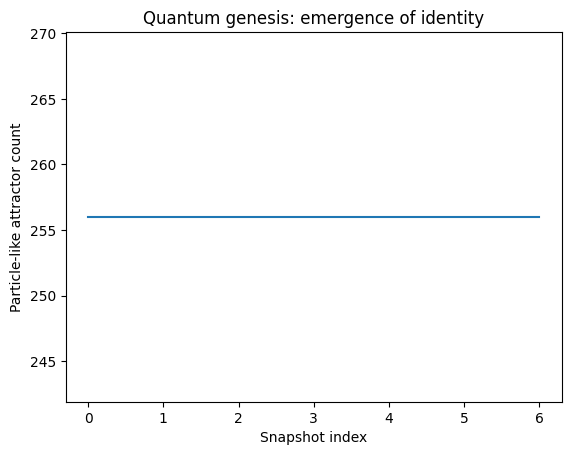

In [6]:
# Visualization: particle count
plt.plot(particle_counts)
plt.xlabel("Snapshot index")
plt.ylabel("Particle-like attractor count")
plt.title("Quantum genesis: emergence of identity")
plt.show()


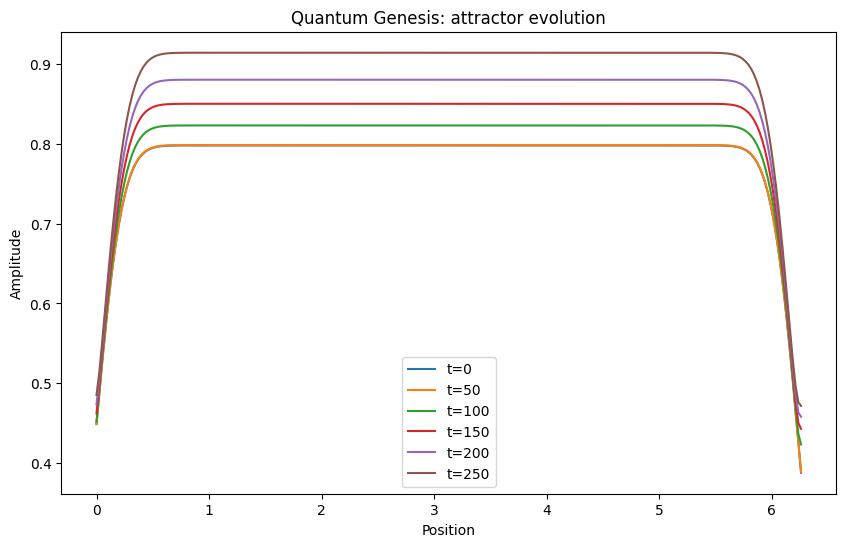

In [7]:
# Visualization: attractor evolution
plt.figure(figsize=(10,6))
for i, h in enumerate(history[:6]):
    plt.plot(x, h, label=f"t={i*50}")
plt.xlabel("Position")
plt.ylabel("Amplitude")
plt.title("Quantum Genesis: attractor evolution")
plt.legend()
plt.show()
